# Etalon Laser Sweep Simulation

This notebook simulates the **measurement** step after calibration, using **controller-style settings** that more closely match the SA201B workflow.

Assumptions in this version:
- waveform is **sawtooth only**
- `MONITOR OUT` is a scaled copy of the sawtooth scan ramp
- sweep expansion changes the **scan time**
- amplitude changes the **optical span per scan**
- DC offset shifts the scan window
- PD gain changes the **measured output voltage scale**

Goal:
- simulate a laser wavelength sweep
- simulate `PD AMPLIFIER OUT` and `MONITOR OUT`
- track one resonance branch scan-to-scan
- estimate **Δf** and **Δλ** from the intensity measurements


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# -----------------------------
# DAQ settings
# -----------------------------
sample_rate = 5000          # Hz
duration = 10               # seconds
t = np.arange(0, duration, 1 / sample_rate)

# -----------------------------
# Controller-style settings
# -----------------------------
waveform_enabled = True     # assume sawtooth only in this notebook
sweep_expansion = 1       # 1, 2, 5, 10, 20, 50, 100
rise_time_setting = 200     # simulated controller knob, 0 to 200
amplitude_vpp = 20.0        # controller amplitude setting
dc_offset_v = 0.0           # controller offset setting
pd_gain_setting = "100k"    # "10k", "100k", or "1M"

# -----------------------------
# Optical / physical settings
# -----------------------------
FSR_GHz = 10.0
lambda0_nm = 635.0
c = 299792458.0

lambda0_m = lambda0_nm * 1e-9
nm_per_GHz = (lambda0_m**2 / c) * 1e9 * 1e9

print("1 GHz ~", nm_per_GHz, "nm")
print("1 FSR ~", FSR_GHz * nm_per_GHz, "nm")

# -----------------------------
# Derived scan settings
# -----------------------------
# Simulate the controller's rise-time behavior:
# 1X sweep expansion corresponds to a base rise time between 0.01 and 0.1 s
rise_time_base = 0.01 + (rise_time_setting / 200.0) * (0.1 - 0.01)

# Sweep expansion stretches the scan time
scan_period = rise_time_base * sweep_expansion

# Simple simulated mapping from controller amplitude to optical span
# Tune fsr_per_volt if you want more/fewer peaks per scan
fsr_per_volt = 0.4
FSR_per_scan = amplitude_vpp * fsr_per_volt

# Simulated mapping from controller DC offset to optical offset
offset_GHz_per_volt = 1.0
scan_offset_GHz = dc_offset_v * offset_GHz_per_volt

print("Base rise time =", rise_time_base, "s")
print("Effective scan period =", scan_period, "s")
print("Estimated FSR per scan =", FSR_per_scan)
print("Scan offset =", scan_offset_GHz, "GHz")

1 GHz ~ 0.0013450138228627488 nm
1 FSR ~ 0.013450138228627489 nm
Base rise time = 0.1 s
Effective scan period = 0.1 s
Estimated FSR per scan = 8.0
Scan offset = 0.0 GHz


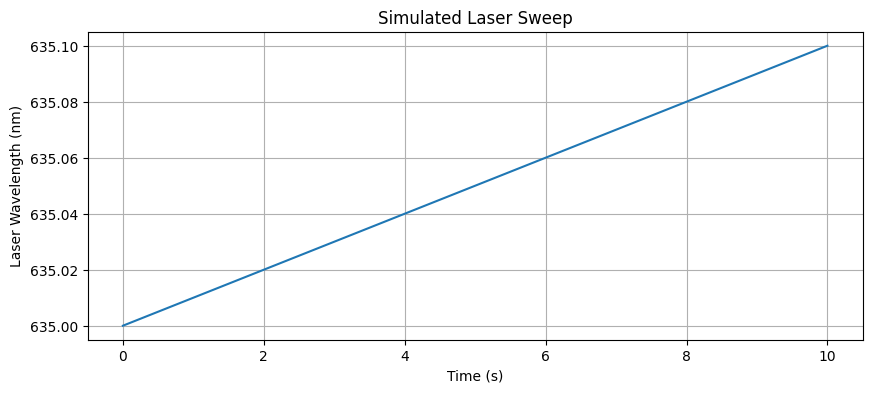

In [3]:
# -----------------------------
# Simulated laser sweep
# -----------------------------
delta_lambda_total_nm = 0.1

laser_lambda_nm = lambda0_nm + delta_lambda_total_nm * (t / duration)
laser_delta_lambda_nm = laser_lambda_nm - laser_lambda_nm[0]
laser_delta_f_GHz = laser_delta_lambda_nm / nm_per_GHz

plt.figure(figsize=(10, 4))
plt.plot(t, laser_lambda_nm)
plt.xlabel("Time (s)")
plt.ylabel("Laser Wavelength (nm)")
plt.title("Simulated Laser Sweep")
plt.grid(True)
plt.show()

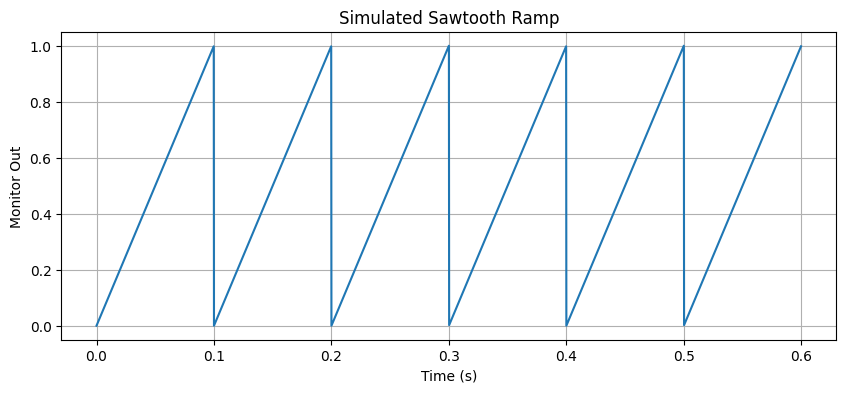

In [4]:
# -----------------------------
# Simulated etalon scan (sawtooth only)
# -----------------------------
if waveform_enabled:
    scan_phase = (t % scan_period) / scan_period
    monitor_out = scan_phase
else:
    scan_phase = np.zeros_like(t)
    monitor_out = np.zeros_like(t)

plt.figure(figsize=(10, 4))
plt.plot(t[:3000], monitor_out[:3000])
plt.xlabel("Time (s)")
plt.ylabel("Monitor Out")
plt.title("Simulated Sawtooth Ramp")
plt.grid(True)
plt.show()

In [5]:
# -----------------------------
# Optical span per scan
# -----------------------------
scan_span_GHz = FSR_per_scan * FSR_GHz

print("Scan span:", scan_span_GHz, "GHz")

Scan span: 80.0 GHz


In [6]:
def wrapped_distance(x, period):
    return np.minimum(np.mod(x, period), period - np.mod(x, period))

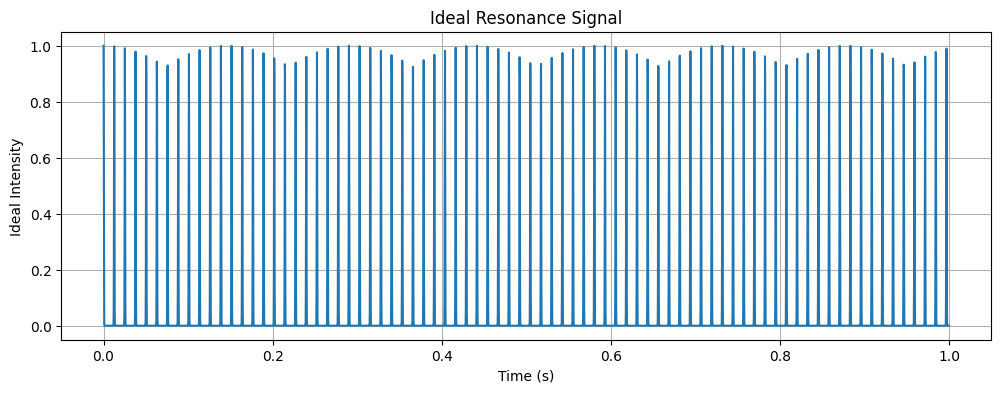

In [7]:
# -----------------------------
# Ideal etalon transmission
# -----------------------------
scan_frequency_GHz = monitor_out * scan_span_GHz + scan_offset_GHz
diff_GHz = scan_frequency_GHz - laser_delta_f_GHz
dist_to_res_GHz = wrapped_distance(diff_GHz, FSR_GHz)

peak_sigma_GHz = 0.20
ideal_intensity = np.exp(-(dist_to_res_GHz**2) / (2 * peak_sigma_GHz**2))

plt.figure(figsize=(12, 4))
plt.plot(t[:5000], ideal_intensity[:5000])
plt.xlabel("Time (s)")
plt.ylabel("Ideal Intensity")
plt.title("Ideal Resonance Signal")
plt.grid(True)
plt.show()

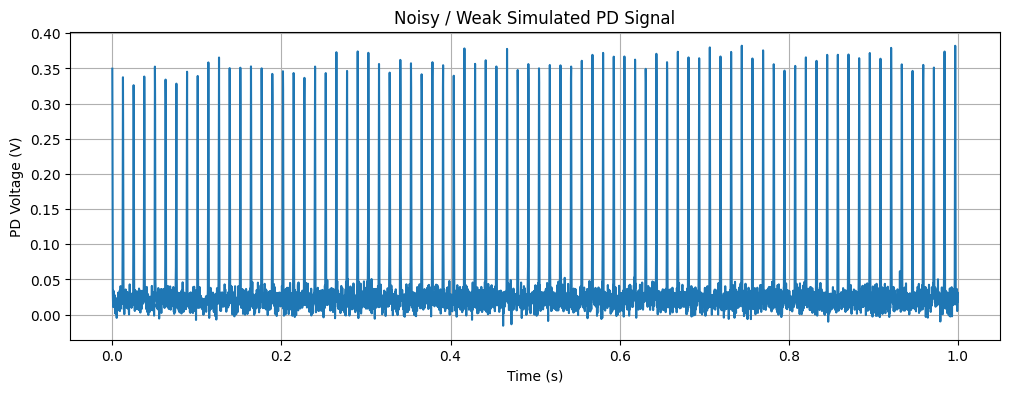

In [8]:
# -----------------------------
# Realistic signal degradation
# -----------------------------
signal_scale = 0.03
baseline = 0.02
white_noise_std = 0.01

drift = (
    0.0008 * np.sin(2*np.pi*0.12*t) +
    0.0005 * np.sin(2*np.pi*0.03*t + 1.2)
)

amp_flicker = 1.0 + 0.25*np.sin(2*np.pi*0.08*t + 0.4)

dropout_mask = np.ones_like(t)
dropout_regions = []
for a, b in dropout_regions:
    dropout_mask[(t >= a) & (t <= b)] = 0.35

rng = np.random.default_rng(7)
spike_noise = np.zeros_like(t)
# set to zeros if you want no random spikes
# spike_idx = rng.choice(len(t), size=20, replace=False)
# spike_noise[spike_idx] = rng.normal(0, 0.001, size=len(spike_idx))

# Simulated PD gain scaling (acts on measured voltage, not optical physics)
if pd_gain_setting == "10k":
    pd_gain_scale = 1.0
elif pd_gain_setting == "100k":
    pd_gain_scale = 10.0
elif pd_gain_setting == "1M":
    pd_gain_scale = 100.0
else:
    raise ValueError("pd_gain_setting must be '10k', '100k', or '1M'")

pd_signal = (
    baseline
    + pd_gain_scale * signal_scale * ideal_intensity * amp_flicker * dropout_mask
    + drift
    + rng.normal(0, white_noise_std, size=len(t))
    + spike_noise
)

plt.figure(figsize=(12, 4))
plt.plot(t[:5000], pd_signal[:5000])
plt.xlabel("Time (s)")
plt.ylabel("PD Voltage (V)")
plt.title("Noisy / Weak Simulated PD Signal")
plt.grid(True)
plt.show()

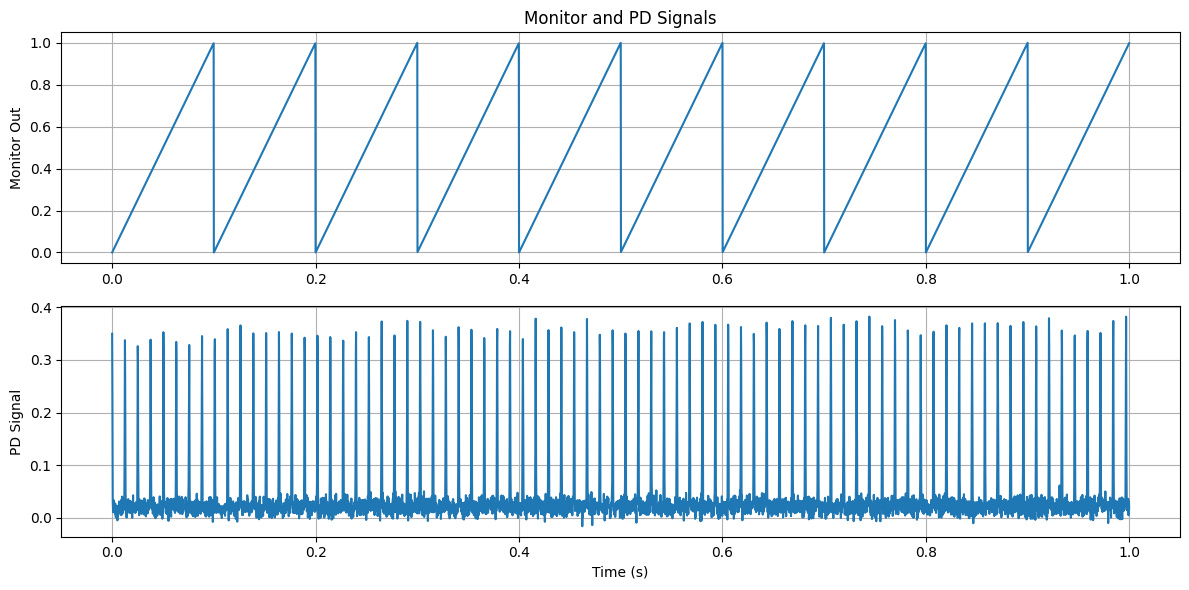

In [9]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t[:5000], monitor_out[:5000])
plt.ylabel("Monitor Out")
plt.title("Monitor and PD Signals")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t[:5000], pd_signal[:5000])
plt.xlabel("Time (s)")
plt.ylabel("PD Signal")
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
dmon = np.diff(monitor_out)
reset_idx = np.where(dmon < -0.5)[0] + 1

scan_boundaries = np.concatenate(([0], reset_idx, [len(t)-1]))
print("Number of scans:", len(scan_boundaries)-1)

Number of scans: 100


In [11]:
scan_peak_times = []
scan_peak_monitor = []
scan_peak_pd = []

prev_monitor = None
peak_prominence = 0.05
max_step = 0.08   # maximum allowed wrapped movement per scan

for i in range(len(scan_boundaries) - 1):
    s = scan_boundaries[i]
    e = scan_boundaries[i + 1]

    seg = pd_signal[s:e]
    seg_mon = monitor_out[s:e]

    local_peaks, props = find_peaks(seg, prominence=peak_prominence)

    if len(local_peaks) == 0:
        continue

    peak_monitors = seg_mon[local_peaks]
    peak_vals = seg[local_peaks]

    if prev_monitor is None:
        # first scan: choose strongest
        chosen_idx = np.argmax(peak_vals)
    else:
        dist = np.abs(peak_monitors - prev_monitor)
        wrapped_dist = np.minimum(dist, 1.0 - dist)

        # only consider peaks that are physically close enough
        valid = wrapped_dist < max_step

        if np.any(valid):
            valid_indices = np.where(valid)[0]
            # among valid ones, choose nearest
            chosen_idx = valid_indices[np.argmin(wrapped_dist[valid])]
        else:
            # no believable continuation found: skip this scan
            continue

    chosen_local = local_peaks[chosen_idx]
    gidx = s + chosen_local

    scan_peak_times.append(t[gidx])
    scan_peak_monitor.append(monitor_out[gidx])
    scan_peak_pd.append(pd_signal[gidx])

    prev_monitor = monitor_out[gidx]

scan_peak_times = np.array(scan_peak_times)
scan_peak_monitor = np.array(scan_peak_monitor)
scan_peak_pd = np.array(scan_peak_pd)

print("Found peaks in", len(scan_peak_times), "scans")

Found peaks in 99 scans


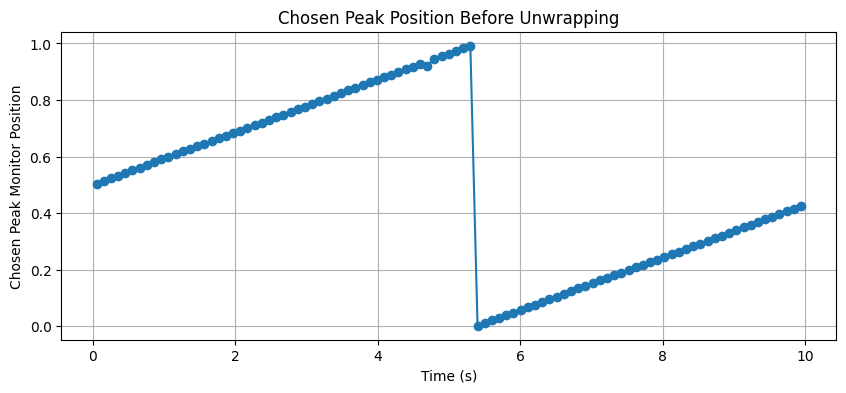

In [12]:
plt.figure(figsize=(10,4))
plt.plot(scan_peak_times, scan_peak_monitor, 'o-')
plt.xlabel("Time (s)")
plt.ylabel("Chosen Peak Monitor Position")
plt.title("Chosen Peak Position Before Unwrapping")
plt.grid(True)
plt.show()

In [18]:
print("peak_fraction start =", peak_fraction[0])
print("peak_fraction_unwrapped start =", peak_fraction_unwrapped[0])
print("peak_fraction_unwrapped end =", peak_fraction_unwrapped[-1])
print("total fractional scan shift =", peak_fraction_unwrapped[-1] - peak_fraction_unwrapped[0])
print("FSR_per_scan =", FSR_per_scan)
print("total FSR shift =", (peak_fraction_unwrapped[-1] - peak_fraction_unwrapped[0]) * FSR_per_scan)
print("estimated final Δλ =", delta_lambda_est_nm[-1])
print("true final Δλ =", true_delta_lambda_at_peaks[-1])

peak_fraction start = 0.504
peak_fraction_unwrapped start = 0.504
peak_fraction_unwrapped end = 1.4240000000000046
total fractional scan shift = 0.9200000000000046
FSR_per_scan = 8.0
total FSR shift = 7.360000000000037
estimated final Δλ = 0.0989930173626988
true final Δλ = 0.09892000000002099


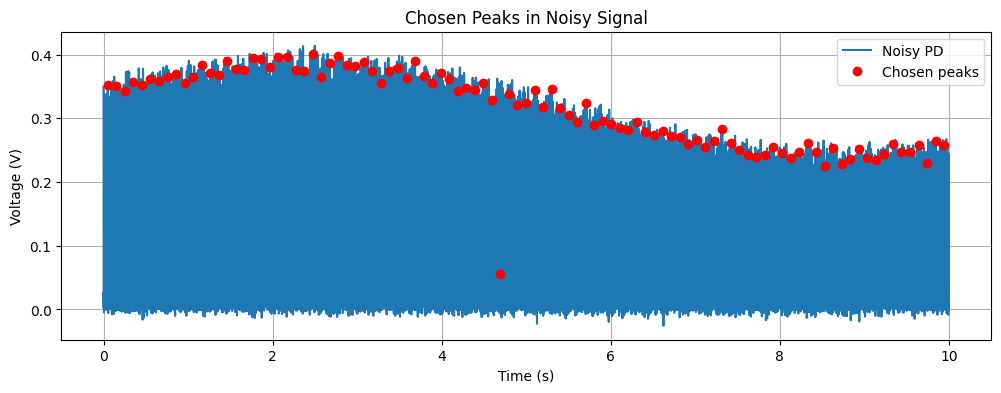

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(t, pd_signal, label="Noisy PD")
plt.plot(scan_peak_times, scan_peak_pd, "ro", label="Chosen peaks")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Chosen Peaks in Noisy Signal")
plt.grid(True)
plt.legend()
plt.show()

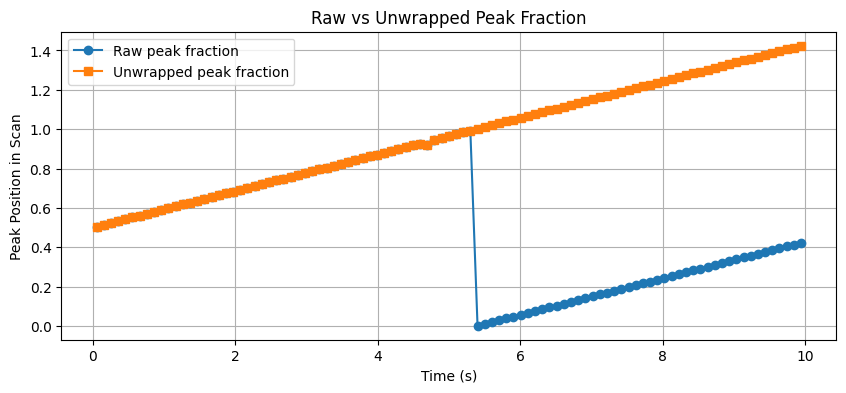

In [15]:
peak_fraction = np.array(scan_peak_monitor)

# Manual unwrapping
peak_fraction_unwrapped = [peak_fraction[0]]
wrap_count = 0

for i in range(1, len(peak_fraction)):
    if peak_fraction[i] < peak_fraction[i-1] - 0.5:
        wrap_count += 1
    elif peak_fraction[i] > peak_fraction[i-1] + 0.5:
        wrap_count -= 1

    peak_fraction_unwrapped.append(peak_fraction[i] + wrap_count)

peak_fraction_unwrapped = np.array(peak_fraction_unwrapped)

plt.figure(figsize=(10, 4))
plt.plot(scan_peak_times, peak_fraction, "o-", label="Raw peak fraction")
plt.plot(scan_peak_times, peak_fraction_unwrapped, "s-", label="Unwrapped peak fraction")
plt.xlabel("Time (s)")
plt.ylabel("Peak Position in Scan")
plt.title("Raw vs Unwrapped Peak Fraction")
plt.grid(True)
plt.legend()
plt.show()

In [16]:
delta_fraction = peak_fraction_unwrapped - peak_fraction_unwrapped[0]
delta_FSR = delta_fraction * FSR_per_scan
delta_f_est_GHz = delta_FSR * FSR_GHz
delta_lambda_est_nm = delta_f_est_GHz * nm_per_GHz

# If the trend is backwards in a given setup, flip sign:
# delta_lambda_est_nm = -delta_lambda_est_nm

true_lambda_at_peaks = np.interp(scan_peak_times, t, laser_lambda_nm)
true_delta_lambda_at_peaks = true_lambda_at_peaks - true_lambda_at_peaks[0]

for i in range(min(10, len(delta_lambda_est_nm))):
    print(
        f"Scan {i}: "
        f"True Δλ = {true_delta_lambda_at_peaks[i]:+.6f} nm, "
        f"Estimated Δλ = {delta_lambda_est_nm[i]:+.6f} nm"
    )

Scan 0: True Δλ = +0.000000 nm, Estimated Δλ = +0.000000 nm
Scan 1: True Δλ = +0.001010 nm, Estimated Δλ = +0.001076 nm
Scan 2: True Δλ = +0.002020 nm, Estimated Δλ = +0.002152 nm
Scan 3: True Δλ = +0.003028 nm, Estimated Δλ = +0.003013 nm
Scan 4: True Δλ = +0.004038 nm, Estimated Δλ = +0.004089 nm
Scan 5: True Δλ = +0.005048 nm, Estimated Δλ = +0.005165 nm
Scan 6: True Δλ = +0.006056 nm, Estimated Δλ = +0.006026 nm
Scan 7: True Δλ = +0.007066 nm, Estimated Δλ = +0.007102 nm
Scan 8: True Δλ = +0.008076 nm, Estimated Δλ = +0.008178 nm
Scan 9: True Δλ = +0.009086 nm, Estimated Δλ = +0.009254 nm


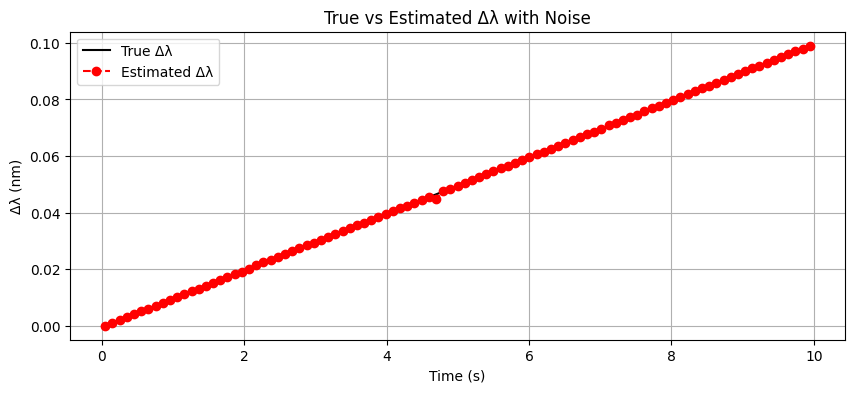

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(scan_peak_times, true_delta_lambda_at_peaks, "k-", label="True Δλ")
plt.plot(scan_peak_times, delta_lambda_est_nm, "ro--", label="Estimated Δλ")
plt.xlabel("Time (s)")
plt.ylabel("Δλ (nm)")
plt.title("True vs Estimated Δλ with Noise")
plt.grid(True)
plt.legend()
plt.show()

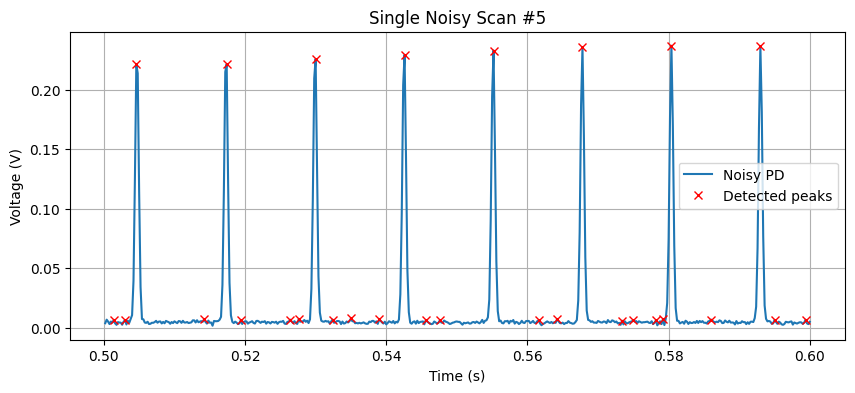

In [84]:
scan_index = 5

s = scan_boundaries[scan_index]
e = scan_boundaries[scan_index + 1]

seg_t = t[s:e]
seg_pd = pd_signal[s:e]

local_peaks, _ = find_peaks(seg_pd, prominence=peak_prominence)

plt.figure(figsize=(10, 4))
plt.plot(seg_t, seg_pd, label="Noisy PD")
plt.plot(seg_t[local_peaks], seg_pd[local_peaks], "rx", label="Detected peaks")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title(f"Single Noisy Scan #{scan_index}")
plt.grid(True)
plt.legend()
plt.show()